In [2]:
#Import libraries
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
dataset_path = '/content/drive/MyDrive/dreaddit_train_cleaned.csv'

df = pd.read_csv(dataset_path)
print(f"Dataset loaded with {len(df)} rows")
print("Columns:", df.columns.tolist())
print("\nSample data:")
df.head()

Dataset loaded with 2821 rows
Columns: ['text', 'label', 'gender', 'age_group', 'mental_health_history', 'therapy_use', 'medication_use', 'trauma_history']

Sample data:


,text,label,gender,age_group,mental_health_history,therapy_use,medication_use,trauma_history
0,"he said he had not felt that way before, sugge...",1,male,50+,unknown,no,no,no
1,"hey there rassistance, not sure if this is the...",0,female,50+,undiagnosed,no,yes,unknown
2,my mom then hit me with the newspaper and it s...,1,unknown,unknown,undiagnosed,yes,no,no
3,"until i met my new boyfriend, he is amazing, h...",1,male,unknown,undiagnosed,yes,yes,yes
4,october is domestic violence awareness month a...,1,male,unknown,diagnosed,unknown,unknown,no


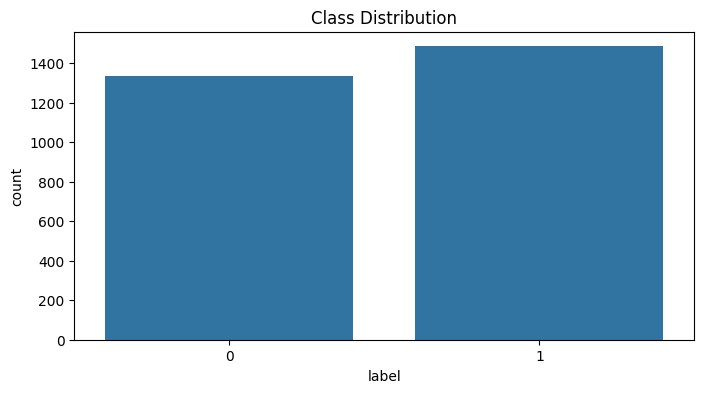

In [5]:
categorical_cols = ['gender', 'age_group', 'mental_health_history', 'therapy_use', 'medication_use', 'trauma_history']
df[categorical_cols] = df[categorical_cols].fillna('unknown')
df = df.dropna(subset=['text', 'label'])

# One-hot encode metadata
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Clean data
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

# Visualize
plt.figure(figsize=(8,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

In [6]:
# Cell 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # Maintain class balance
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

print(f"Train: {len(X_train)} samples")
print(f"Val: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Train: 2256 samples
Val: 282 samples
Test: 283 samples


In [7]:
#Create PyTorch Dataset class
class TextMetaDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.meta = df.drop(columns=['text', 'label']).values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'meta': torch.tensor(self.meta[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [9]:
from transformers import RobertaModel
import torch.nn as nn

class RobertaWithMetadata(nn.Module):
    def __init__(self, meta_input_dim):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        self.meta_fc = nn.Linear(meta_input_dim, 32)
        self.classifier = nn.Linear(self.roberta.config.hidden_size + 32, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, meta):
        roberta_out = self.roberta(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        meta_out = torch.relu(self.meta_fc(meta))
        combined = torch.cat((roberta_out, meta_out), dim=1)
        return self.classifier(self.dropout(combined))

In [10]:
#Initialize tokenizer - USING STANDARD ROBERTA-BASE
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Verify tokenization
sample_text = X_train.iloc[0] if isinstance(X_train, pd.Series) else X_train[0]
print("Sample tokenization:")
print(f"Text: {sample_text[:100]}...")
print(f"Tokenized: {tokenizer.tokenize(sample_text)[:20]}...")

# Create datasets
train_df, val_df = train_test_split(df_encoded, test_size=0.2, stratify=df_encoded['label'], random_state=42)

# Create DataLoaders with smaller batch size
BATCH_SIZE = 16

train_dataset = TextMetaDataset(train_df, tokenizer)
val_dataset = TextMetaDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("\nDataLoaders created!")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Sample tokenization:
Text: we added a bunch of security for specific scenarios. if youre more comfortable keeping things on red...
Tokenized: ['we', 'Ġadded', 'Ġa', 'Ġbunch', 'Ġof', 'Ġsecurity', 'Ġfor', 'Ġspecific', 'Ġscenarios', '.', 'Ġif', 'Ġyou', 're', 'Ġmore', 'Ġcomfortable', 'Ġkeeping', 'Ġthings', 'Ġon', 'Ġreddit', ',']...

DataLoaders created!
Batch size: 16
Train batches: 141
Val batches: 36


In [20]:
import torch
import torch.nn.functional as F
from torch import optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RobertaWithMetadata(meta_input_dim=train_df.shape[1] - 2).to(device)  # -2 for 'text' and 'label'

optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        meta = batch['meta'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
def evaluate_loss():
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            meta = batch['meta'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(val_loader)


In [14]:
from sklearn.metrics import classification_report

def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            meta = batch['meta'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, digits=3))


In [22]:
EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss = train_one_epoch()
    val_loss = evaluate_loss()
    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
    evaluate()


Epoch 1/3


100%|██████████| 141/141 [00:54<00:00,  2.59it/s]


Train loss: 0.5320 | Val loss: 0.4133
              precision    recall  f1-score   support

           0      0.857     0.672     0.753       268
           1      0.752     0.899     0.819       297

    accuracy                          0.791       565
   macro avg      0.805     0.785     0.786       565
weighted avg      0.802     0.791     0.788       565


Epoch 2/3


100%|██████████| 141/141 [00:51<00:00,  2.74it/s]


Train loss: 0.3309 | Val loss: 0.3986
              precision    recall  f1-score   support

           0      0.820     0.780     0.799       268
           1      0.810     0.845     0.827       297

    accuracy                          0.814       565
   macro avg      0.815     0.812     0.813       565
weighted avg      0.814     0.814     0.814       565


Epoch 3/3


100%|██████████| 141/141 [00:51<00:00,  2.73it/s]


Train loss: 0.2133 | Val loss: 0.5184
              precision    recall  f1-score   support

           0      0.913     0.627     0.743       268
           1      0.738     0.946     0.829       297

    accuracy                          0.795       565
   macro avg      0.825     0.786     0.786       565
weighted avg      0.821     0.795     0.788       565



In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix():
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            meta = batch['meta'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

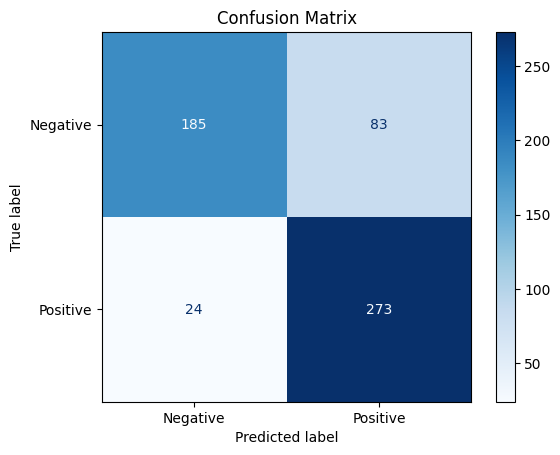

In [19]:
plot_confusion_matrix()

In [23]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

def evaluate_full():
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            meta = batch['meta'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary')  # use 'macro' or 'weighted' for multi-class
    recall = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=3))


In [24]:
evaluate_full()

Accuracy: 0.795
Precision: 0.738
Recall: 0.946
F1-score: 0.829

Classification Report:
              precision    recall  f1-score   support

           0      0.913     0.627     0.743       268
           1      0.738     0.946     0.829       297

    accuracy                          0.795       565
   macro avg      0.825     0.786     0.786       565
weighted avg      0.821     0.795     0.788       565



In [25]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 18.5 MB/s eta 0:00:00


In [26]:
# Load fresh original (non-encoded) version of the val set
val_sensitive = df.loc[val_df.index].reset_index(drop=True)
val_preds = []
val_labels = []

In [27]:
model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        meta = batch['meta'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
        preds = torch.argmax(outputs, dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())


In [29]:
# Combine results
val_sensitive['pred'] = val_preds
val_sensitive['label'] = val_labels

# Set protected attribute: e.g., 'age_group' or 'gender'
protected_attr = 'age_group'

groups = val_sensitive[protected_attr].unique()
metrics = []

for group in groups:
    group_data = val_sensitive[val_sensitive[protected_attr] == group]
    tp = ((group_data['label'] == 1) & (group_data['pred'] == 1)).sum()
    tn = ((group_data['label'] == 0) & (group_data['pred'] == 0)).sum()
    fp = ((group_data['label'] == 0) & (group_data['pred'] == 1)).sum()
    fn = ((group_data['label'] == 1) & (group_data['pred'] == 0)).sum()

    total = len(group_data)
    pos_rate = (tp + fp) / total if total > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    metrics.append({
        'group': group,
        'pos_rate (Demographic Parity)': round(pos_rate, 3),
        'TPR (Equal Opportunity)': round(tpr, 3),
        'FPR (Equalized Odds)': round(fpr, 3),
        'count': total
    })

fairness_df = pd.DataFrame(metrics)
print(fairness_df)


     group  pos_rate (Demographic Parity)  TPR (Equal Opportunity)  \
0    13-17                          0.611                    0.891   
1  unknown                          0.784                    0.956   
2    35-49                          0.673                    0.909   
3      50+                          0.649                    0.960   
4    18-24                          0.695                    0.966   
5    25-34                          0.653                    1.000   

   FPR (Equalized Odds)  count  
0                 0.318     90  
1                 0.517     74  
2                 0.408    104  
3                 0.319     97  
4                 0.362    105  
5                 0.365     95  


In [32]:
def compute_dpd_binary(y_pred, sensitive_attrs, attr_name):
    df = pd.DataFrame({
        'pred': y_pred,
        'sensitive': sensitive_attrs
    })

    dpd_values = []
    for label in [0, 1]:
        df_label = df[df['pred'] == label]
        groups = df['sensitive'].unique()
        group_rates = []

        for group in groups:
            total_group = df[df['sensitive'] == group].shape[0]
            positive_in_group = df_label[df_label['sensitive'] == group].shape[0]
            rate = positive_in_group / total_group if total_group > 0 else 0
            group_rates.append(rate)

        # Max pairwise difference in positive prediction rates
        dpd = max(group_rates) - min(group_rates)
        dpd_values.append(dpd)

    return dpd_values


In [33]:
def plot_fairness_binary(dpd_gender, dpd_age):
    labels = ['Class 0', 'Class 1']
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6, 5))
    plt.bar(x - width/2, dpd_gender, width, label='DPD Gender')
    plt.bar(x + width/2, dpd_age, width, label='DPD Age')

    plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
    plt.xticks(x, labels)
    plt.ylabel('Demographic Parity Difference')
    plt.title('Fairness Metrics by Class')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [47]:
def get_predictions(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            meta = batch['meta'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, meta=meta)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

In [49]:
print(val_df.columns)


Index(['text', 'label', 'gender_female', 'gender_male', 'gender_unknown',
       'age_group_13-17', 'age_group_18-24', 'age_group_25-34',
       'age_group_35-49', 'age_group_50+', 'age_group_unknown',
       'mental_health_history_diagnosed', 'mental_health_history_undiagnosed',
       'mental_health_history_unknown', 'therapy_use_no',
       'therapy_use_unknown', 'therapy_use_yes', 'medication_use_no',
       'medication_use_unknown', 'medication_use_yes', 'trauma_history_no',
       'trauma_history_unknown', 'trauma_history_yes'],
      dtype='object')


In [50]:
# Gender columns
gender_cols = ['gender_female', 'gender_male', 'gender_unknown']
# Age group columns
age_group_cols = [
    'age_group_13-17', 'age_group_18-24', 'age_group_25-34',
    'age_group_35-49', 'age_group_50+', 'age_group_unknown'
]

# Convert one-hot to string labels
gender_list = val_df[gender_cols].idxmax(axis=1).str.replace('gender_', '')
age_group_list = val_df[age_group_cols].idxmax(axis=1).str.replace('age_group_', '')


In [54]:
# Assume model and val_loader already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_true, y_pred = get_predictions(model, val_loader, device)

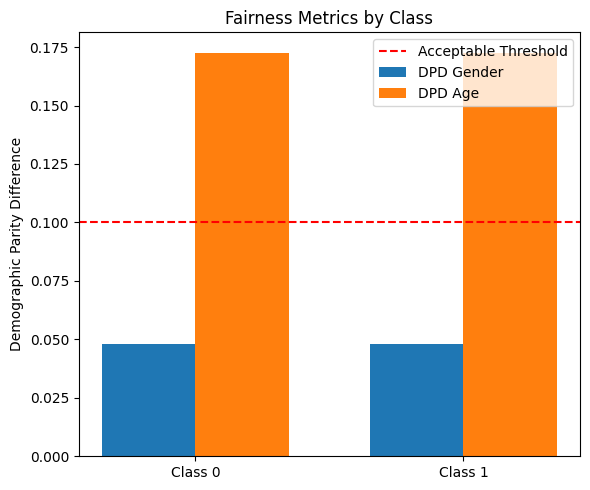

In [55]:
# sensitive attributes should be lists of same length as y_pred
dpd_gender = compute_dpd_binary(y_pred, gender_list, 'gender')
dpd_age = compute_dpd_binary(y_pred, age_group_list, 'age_group')

plot_fairness_binary(dpd_gender, dpd_age)